# 📊 EDA & Visualisasi — BISINDO Sign Language Recognition

Notebook ini berisi tiga analisis utama untuk mendukung argumen metodologi di sidang:

| # | Visualisasi | Tujuan |
|---|-------------|--------|
| 1 | **Pseudo-Image Spectrogram** | Membuktikan setiap kelas gesture membentuk "tekstur" unik |
| 2 | **t-SNE Clustering** | Membuktikan 10 kelas gesture terpisah secara geometris |
| 3 | **Histogram Distribusi Frame** | Membuktikan `target_frames=90` adalah pilihan optimal |

---
## 0. Setup & Imports

In [1]:
import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Path setup (relatif dari src/notebooks/) ──────────────────────────────
NOTEBOOK_DIR   = Path().resolve()                    # .../src/notebooks/
PROJECT_ROOT   = NOTEBOOK_DIR.parents[1]             # .../project_root/
NPY_DIR        = PROJECT_ROOT / 'data' / 'processed' / 'npy'
EXTRACTED_DIR  = PROJECT_ROOT / 'data' / 'interim'  / 'landmarks_extracted'
NORM_DIR       = PROJECT_ROOT / 'data' / 'interim'  / 'landmarks_normalization'
OUTPUT_DIR     = PROJECT_ROOT / 'outputs' / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'NPY dir      : {NPY_DIR}')
print(f'Output plots : {OUTPUT_DIR}')

Project root : C:\Users\hp\multimedia\ta-code
NPY dir      : C:\Users\hp\multimedia\ta-code\data\processed\npy
Output plots : C:\Users\hp\multimedia\ta-code\outputs\plots


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
X      = np.load(NPY_DIR / 'X.npy')        # (N, 90, 122, 2)
y      = np.load(NPY_DIR / 'y.npy')        # (N,)
labels = np.load(NPY_DIR / 'labels.npy')   # (10,) string array

N, T, L, C = X.shape
print(f'X shape  : {X.shape}  → (N={N}, T={T} frames, L={L} landmarks, C={C} coords)')
print(f'y shape  : {y.shape}')
print(f'Classes  : {list(labels)}')
print(f'Samples per class: {dict(zip(labels, np.bincount(y)))}')

X shape  : (150, 90, 122, 2)  → (N=150, T=90 frames, L=122 landmarks, C=2 coords)
y shape  : (150,)
Classes  : ['belum', 'hati_hati', 'hobi', 'izin', 'maaf', 'sahabat', 'teman', 'terima_kasih', 'tidak_punya', 'ulang']
Samples per class: {'belum': 15, 'hati_hati': 15, 'hobi': 15, 'izin': 15, 'maaf': 15, 'sahabat': 15, 'teman': 15, 'terima_kasih': 15, 'tidak_punya': 15, 'ulang': 15}


In [3]:
# ── Color palette (1 warna per kelas, konsisten di semua plot) ────────────
CLASS_COLORS = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261',
    '#264653', '#8338EC', '#06D6A0', '#FB5607', '#3A86FF'
]
COLOR_MAP = {label: CLASS_COLORS[i] for i, label in enumerate(labels)}

print('Palette siap:', COLOR_MAP)

Palette siap: {'belum': '#E63946', 'hati_hati': '#457B9D', 'hobi': '#2A9D8F', 'izin': '#E9C46A', 'maaf': '#F4A261', 'sahabat': '#264653', 'teman': '#8338EC', 'terima_kasih': '#06D6A0', 'tidak_punya': '#FB5607', 'ulang': '#3A86FF'}


---
## 1. Pseudo-Image Spectrogram

**Cara kerja:**  
`X[i]` shape `(90, 122, 2)` → flatten landmark+coord → `(90, 244)` sebagai *raw features*  
Kemudian hitung Δ (velocity) → concat `[x,y,Δx,Δy]` → `(90, 488)` sebagai *full features*

Plot sisi-sisi untuk membuktikan setiap kata punya "sidik jari" visual yang unik.

In [18]:
def compute_pseudo_image(sample: np.ndarray, include_delta: bool = True) -> np.ndarray:
    """
    Input : (T, L, 2)  → float32
    Output: (T, L*2)   jika include_delta=False
            (T, L*4)   jika include_delta=True  [x,y,Δx,Δy]
    """
    T, L, _ = sample.shape
    xy = sample.reshape(T, L * 2)                  # (T, 244)

    if not include_delta:
        return xy

    delta = np.diff(sample, axis=0, prepend=sample[:1])   # (T, L, 2)
    dxy   = delta.reshape(T, L * 2)                        # (T, 244)
    return np.concatenate([xy, dxy], axis=1)               # (T, 488)


def normalize_for_display(img):
    p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
    img = np.clip(img, p2, p98)
    return (img - p2) / (p98 - p2 + 1e-8)

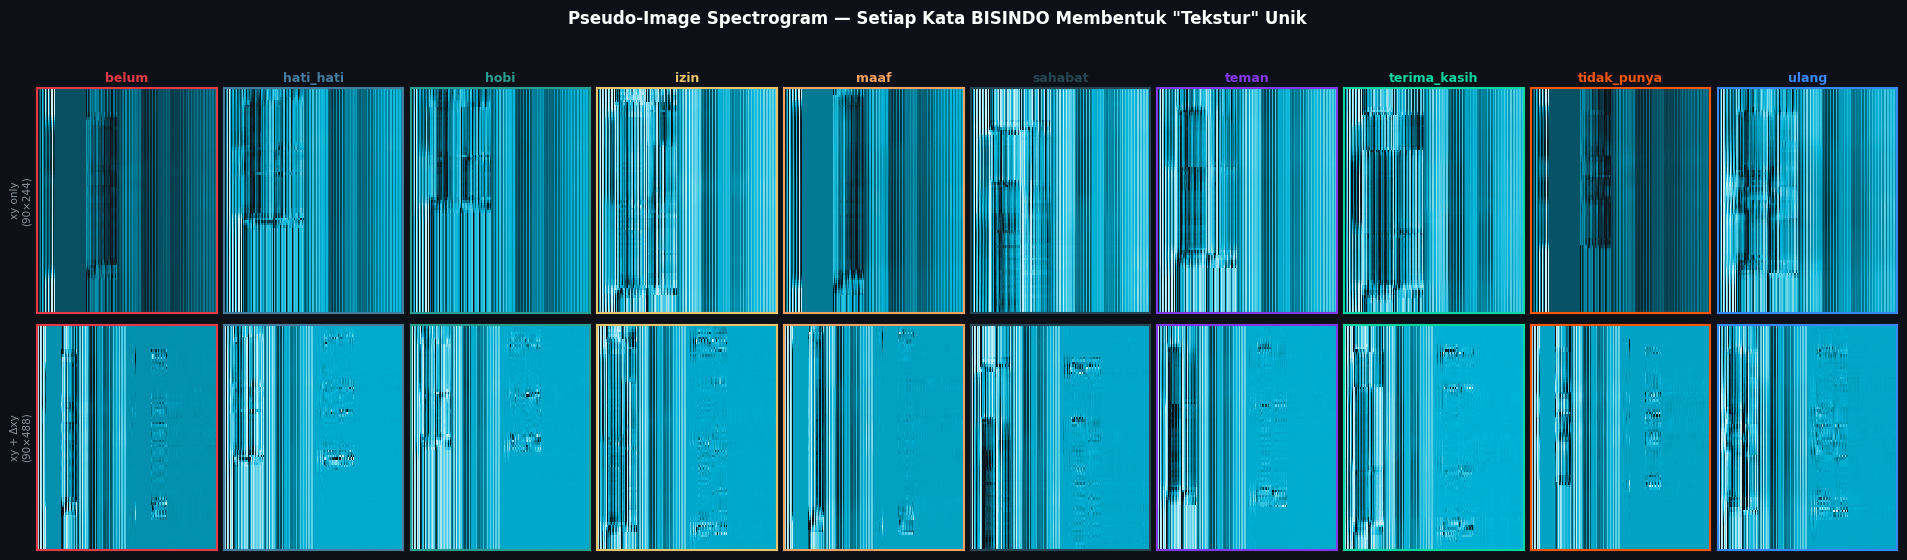

✓ Saved → outputs/plots/01_pseudo_image_spectrogram.png


In [19]:
# ── Plot: 1 sampel per kelas, 2 baris (raw xy | full xy+delta) ───────────
n_classes = len(labels)
cmap_spec  = LinearSegmentedColormap.from_list('bisindo', ['#0d1117', '#00b4d8', '#caf0f8'])

fig, axes = plt.subplots(
    nrows=2, ncols=n_classes,
    figsize=(n_classes * 2.4, 6),
    gridspec_kw={'hspace': 0.05, 'wspace': 0.04}
)
fig.patch.set_facecolor('#0d1117')

row_labels = ['xy only\n(90×244)', 'xy + Δxy\n(90×488)']

for col, (cls_idx, lbl) in enumerate(zip(range(n_classes), labels)):
    # Ambil klip pertama dari kelas ini
    sample_idx = np.where(y == cls_idx)[0][0]
    sample     = X[sample_idx]                         # (90, 122, 2)

    for row, include_delta in enumerate([False, True]):
        img = compute_pseudo_image(sample, include_delta=include_delta)
        img = normalize_for_display(img)

        ax = axes[row, col]
        ax.imshow(img, aspect='auto', cmap=cmap_spec, interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_edgecolor(COLOR_MAP[lbl])
            spine.set_linewidth(1.5)

        if row == 0:
            ax.set_title(lbl, color=COLOR_MAP[lbl], fontsize=9,
                         fontweight='bold', pad=4)

        if col == 0:
            ax.set_ylabel(row_labels[row], color='#8b949e',
                          fontsize=7.5, labelpad=4)

fig.suptitle(
    'Pseudo-Image Spectrogram — Setiap Kata BISINDO Membentuk "Tekstur" Unik',
    color='white', fontsize=12, fontweight='bold', y=1.01
)

plt.savefig(OUTPUT_DIR / '01_pseudo_image_spectrogram.png',
            dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved → outputs/plots/01_pseudo_image_spectrogram.png')

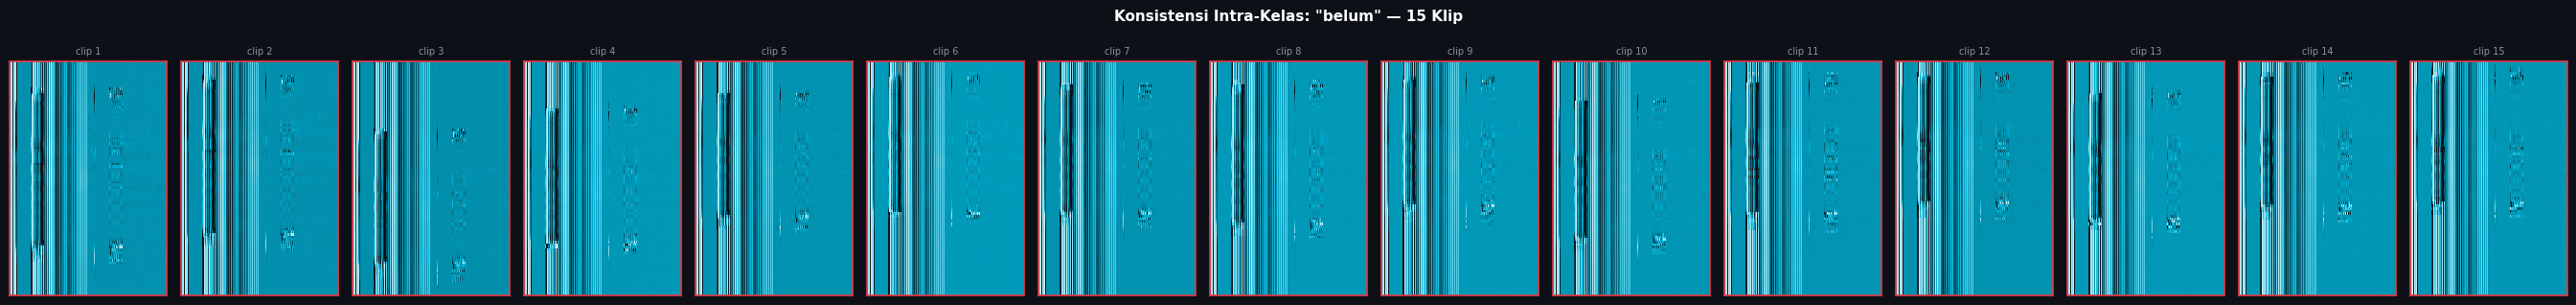

In [20]:
# ── Bonus: tampilkan semua klip 1 kelas untuk lihat konsistensi intra-kelas
TARGET_CLASS = labels[0]   # ← ganti nama kelas sesuai kebutuhan
cls_idx   = np.where(labels == TARGET_CLASS)[0][0]
cls_samples = X[y == cls_idx]                          # (15, 90, 122, 2)

n_clips = len(cls_samples)
fig, axes = plt.subplots(1, n_clips, figsize=(n_clips * 1.8, 3.2))
fig.patch.set_facecolor('#0d1117')

for i, ax in enumerate(axes):
    img = compute_pseudo_image(cls_samples[i], include_delta=True)
    ax.imshow(normalize_for_display(img), aspect='auto',
              cmap=cmap_spec, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'clip {i+1}', color='#8b949e', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor(COLOR_MAP[TARGET_CLASS])
        spine.set_linewidth(1.2)

fig.suptitle(
    f'Konsistensi Intra-Kelas: "{TARGET_CLASS}" — 15 Klip',
    color='white', fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'01b_intraclass_{TARGET_CLASS}.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 2. t-SNE Clustering

**Cara kerja:**  
Setiap klip di-flatten menjadi 1 vektor `(90×488,)` = 43.920 dimensi.  
t-SNE kompres ke 2D. Jika kelas ter-cluster rapi → model *pasti* bisa belajar.

> ⚠️ **Catatan metodologi:** t-SNE dijalankan pada *seluruh* data (150 sampel) **hanya untuk visualisasi EDA**, bukan untuk training. Ini valid karena t-SNE tidak menghasilkan parameter yang digunakan model.

In [21]:
# ── Flatten & scale ───────────────────────────────────────────────────────
print('Menghitung pseudo-image untuk semua sampel...')
X_pseudo = np.stack(
    [compute_pseudo_image(X[i], include_delta=True).ravel() for i in range(N)],
    axis=0
)  # (150, 90*488) = (150, 43920)

print(f'X_pseudo shape: {X_pseudo.shape}')

# StandardScaler agar t-SNE tidak bias ke fitur besar
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_pseudo)
print('Scaling selesai.')

Menghitung pseudo-image untuk semua sampel...
X_pseudo shape: (150, 43920)
Scaling selesai.


In [22]:
# ── Jalankan t-SNE ────────────────────────────────────────────────────────
# perplexity=10 untuk dataset kecil (N=150, ~15 per kelas)
# n_iter=1000 cukup untuk konvergensi
print('Menjalankan t-SNE (perplexity=10, max_iter=1000)...')
tsne = TSNE(
    n_components=2,
    perplexity=10,
    max_iter=1000,        # ← ganti dari n_iter
    learning_rate='auto',
    init='pca',
    random_state=42,
    verbose=1
)
X_2d = tsne.fit_transform(X_scaled)
print(f't-SNE selesai. Shape: {X_2d.shape}')

Menjalankan t-SNE (perplexity=10, max_iter=1000)...
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.014s...
[t-SNE] Computed neighbors for 150 samples in 1.024s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 72.795507
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.228519
[t-SNE] KL divergence after 1000 iterations: 0.261254
t-SNE selesai. Shape: (150, 2)


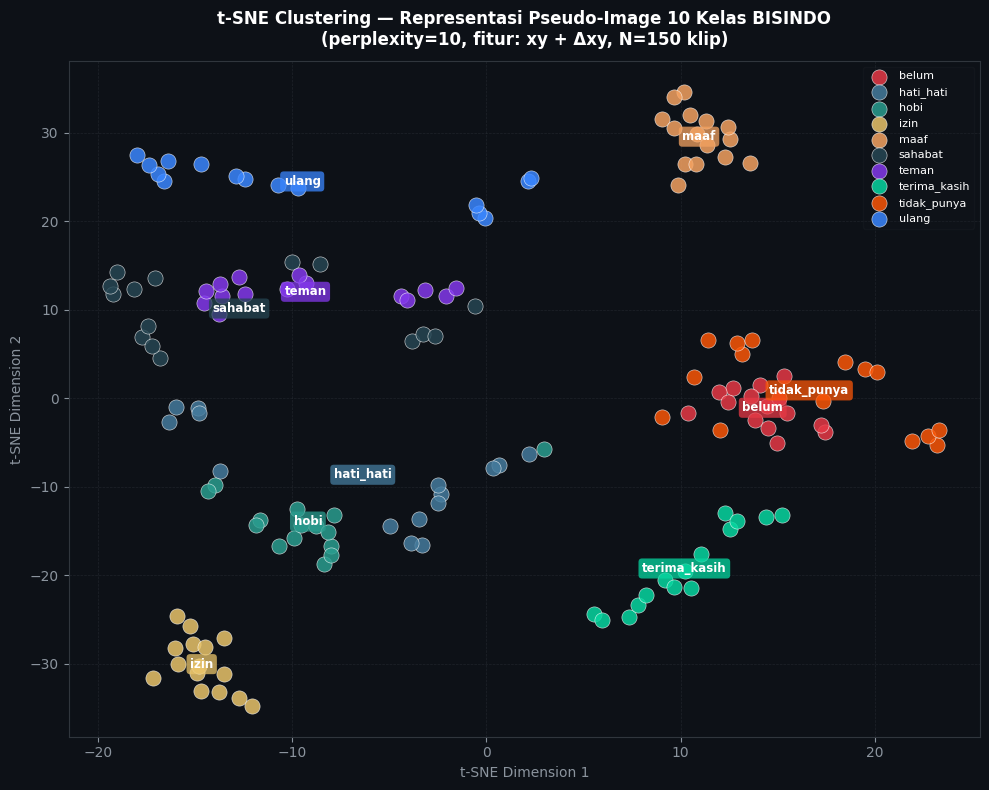

✓ Saved → outputs/plots/02_tsne_clustering.png


In [23]:
# ── Plot t-SNE ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

for cls_idx, lbl in enumerate(labels):
    mask = y == cls_idx
    pts  = X_2d[mask]
    color = CLASS_COLORS[cls_idx]

    # Titik-titik
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=color, s=120, alpha=0.85,
        edgecolors='white', linewidths=0.4,
        zorder=3, label=lbl
    )

    # Label centroid
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.text(
        cx, cy, lbl,
        color='white', fontsize=8.5, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.75, edgecolor='none'),
        zorder=4
    )

# Grid tipis
ax.grid(color='#30363d', linewidth=0.5, linestyle='--', alpha=0.5)
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

ax.set_xlabel('t-SNE Dimension 1', color='#8b949e', fontsize=10)
ax.set_ylabel('t-SNE Dimension 2', color='#8b949e', fontsize=10)
ax.set_title(
    't-SNE Clustering — Representasi Pseudo-Image 10 Kelas BISINDO\n'
    '(perplexity=10, fitur: xy + Δxy, N=150 klip)',
    color='white', fontsize=12, fontweight='bold', pad=12
)

legend = ax.legend(
    loc='upper right', framealpha=0.15,
    facecolor='#161b22', edgecolor='#30363d',
    labelcolor='white', fontsize=8
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_tsne_clustering.png',
            dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved → outputs/plots/02_tsne_clustering.png')

In [24]:
# ── Analisis kuantitatif: intra vs inter-class distance ───────────────────
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_2d, y)
print(f'Silhouette Score (t-SNE 2D): {sil:.4f}')
print()
print('Interpretasi:')
print(f'  > 0.5  → Cluster sangat rapi  ✓')
print(f'  0.2–0.5 → Cluster cukup baik')
print(f'  < 0.2  → Overlap antar kelas')
print()
print(f'  Skor kamu: {sil:.4f} →', (
    '✅ Sangat layak untuk klasifikasi' if sil > 0.5
    else '⚠️ Cluster terbentuk tapi ada overlap' if sil > 0.2
    else '❌ Perlu review preprocessing'
))

Silhouette Score (t-SNE 2D): 0.3540

Interpretasi:
  > 0.5  → Cluster sangat rapi  ✓
  0.2–0.5 → Cluster cukup baik
  < 0.2  → Overlap antar kelas

  Skor kamu: 0.3540 → ⚠️ Cluster terbentuk tapi ada overlap


---
## 3. Histogram Distribusi Frame

**Tujuan:** Membuktikan secara statistik bahwa `target_frames=90` adalah pilihan normalisasi temporal yang tepat — bukan angka sembarangan.

Kita bandingkan:
- **Pre-crop** (dari `landmarks_extracted/`) → distribusi asli dari video
- **Post-crop** (dari `landmarks_normalization/`) → hasil setelah preprocessing

In [14]:
def collect_frame_counts(json_root: Path) -> dict:
    """
    Jelajahi semua subdirektori label di json_root.
    Return: {'label': [frame_count, ...], ...}
    """
    result = {}
    for label_dir in sorted(json_root.iterdir()):
        if not label_dir.is_dir():
            continue
        counts = []
        for jf in sorted(label_dir.glob('*.json')):
            with open(jf) as f:
                data = json.load(f)
            # Ambil total_frames dari metadata atau hitung langsung
            n_frames = data.get('metadata', {}).get('total_frames',
                       len(data.get('frames', [])))
            counts.append(int(n_frames))
        if counts:
            result[label_dir.name] = counts
    return result


print('Membaca frame counts dari extracted (pre-crop)...')
counts_pre  = collect_frame_counts(EXTRACTED_DIR)

print('Membaca frame counts dari normalization (post-crop)...')
counts_post = collect_frame_counts(NORM_DIR)

# Flatten ke list angka
all_pre  = [c for v in counts_pre.values()  for c in v]
all_post = [c for v in counts_post.values() for c in v]

print(f'\nPre-crop  — N={len(all_pre):3d}  min={min(all_pre):3d}  '
      f'median={int(np.median(all_pre)):3d}  max={max(all_pre):3d}  '
      f'mean={np.mean(all_pre):.1f}')
print(f'Post-crop — N={len(all_post):3d}  min={min(all_post):3d}  '
      f'median={int(np.median(all_post)):3d}  max={max(all_post):3d}  '
      f'mean={np.mean(all_post):.1f}')

Membaca frame counts dari extracted (pre-crop)...
Membaca frame counts dari normalization (post-crop)...

Pre-crop  — N=150  min= 90  median= 90  max=103  mean=90.5
Post-crop — N=150  min= 90  median= 90  max= 90  mean=90.0


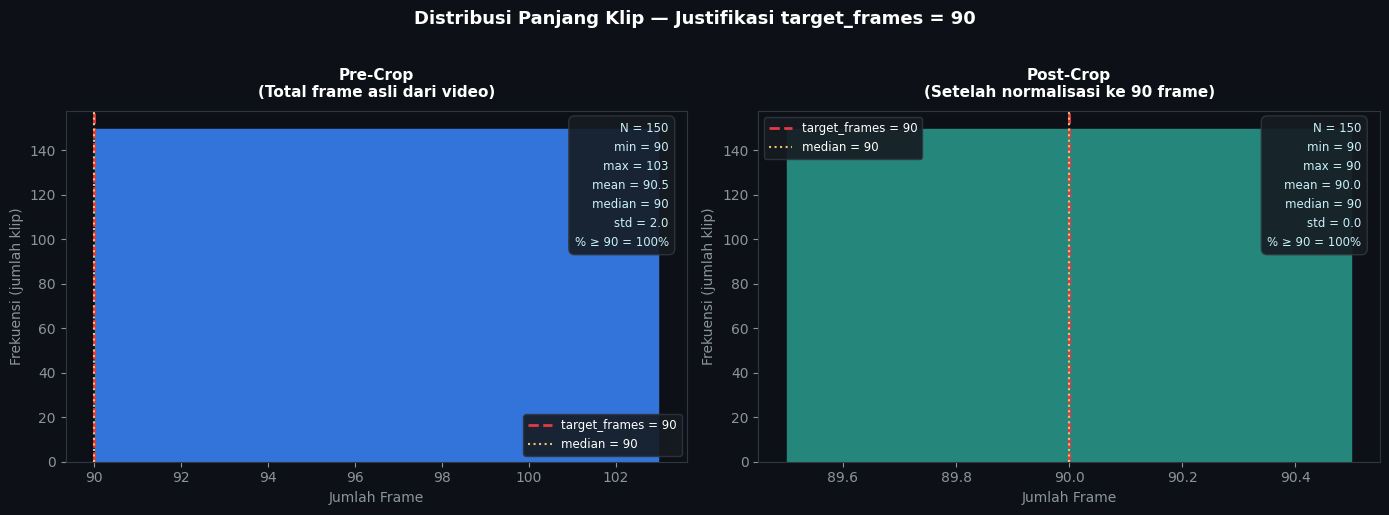

✓ Saved → outputs/plots/03_frame_distribution.png


In [15]:
# ── Plot histogram ────────────────────────────────────────────────────────
TARGET = 90

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.patch.set_facecolor('#0d1117')

datasets = [
    (all_pre,  axes[0], 'Pre-Crop\n(Total frame asli dari video)',     '#3A86FF'),
    (all_post, axes[1], 'Post-Crop\n(Setelah normalisasi ke 90 frame)', '#2A9D8F'),
]

for data_arr, ax, title, color in datasets:
    ax.set_facecolor('#0d1117')

    # Auto bin width (Freedman-Diaconis)
    n, bins, patches = ax.hist(
        data_arr, bins='fd', color=color,
        edgecolor='#0d1117', linewidth=0.5, alpha=0.85
    )

    # Garis target
    ax.axvline(TARGET, color='#E63946', linewidth=2, linestyle='--',
               label=f'target_frames = {TARGET}', zorder=5)

    # Garis median
    med = np.median(data_arr)
    ax.axvline(med, color='#E9C46A', linewidth=1.5, linestyle=':',
               label=f'median = {med:.0f}', zorder=5)

    # Statistik annotation
    stats_txt = (
        f'N = {len(data_arr)}\n'
        f'min = {min(data_arr)}\n'
        f'max = {max(data_arr)}\n'
        f'mean = {np.mean(data_arr):.1f}\n'
        f'median = {med:.0f}\n'
        f'std = {np.std(data_arr):.1f}\n'
        f'% ≥ 90 = {100*np.mean(np.array(data_arr)>=TARGET):.0f}%'
    )
    ax.text(
        0.97, 0.97, stats_txt,
        transform=ax.transAxes, va='top', ha='right',
        color='#caf0f8', fontsize=8.5, linespacing=1.6,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#161b22',
                  edgecolor='#30363d', alpha=0.9)
    )

    ax.set_xlabel('Jumlah Frame', color='#8b949e', fontsize=10)
    ax.set_ylabel('Frekuensi (jumlah klip)', color='#8b949e', fontsize=10)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='#8b949e')
    ax.legend(fontsize=8.5, facecolor='#161b22', edgecolor='#30363d',
              labelcolor='white', framealpha=0.9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

fig.suptitle(
    'Distribusi Panjang Klip — Justifikasi target_frames = 90',
    color='white', fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_frame_distribution.png',
            dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved → outputs/plots/03_frame_distribution.png')

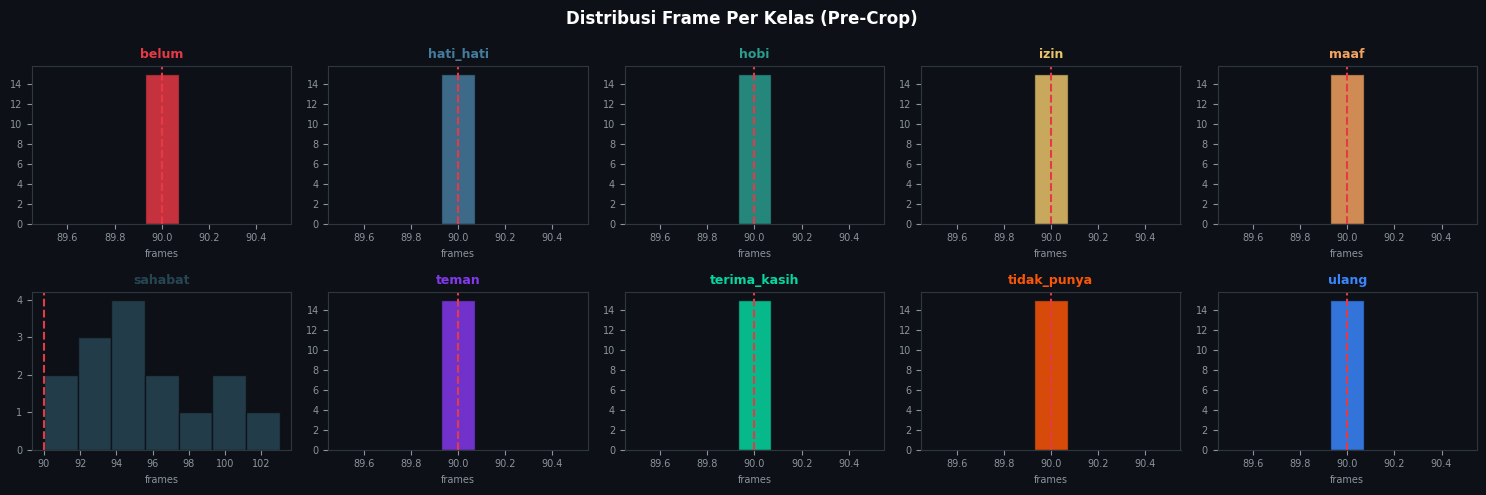

In [16]:
# ── Histogram per kelas (pre-crop) untuk cek outlier ─────────────────────
n_cls = len(counts_pre)
ncols = 5
nrows = (n_cls + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5),
                         sharey=False)
fig.patch.set_facecolor('#0d1117')
axes_flat = axes.ravel() if nrows > 1 else axes

for col_idx, (lbl, counts) in enumerate(counts_pre.items()):
    ax = axes_flat[col_idx]
    ax.set_facecolor('#0d1117')
    color = COLOR_MAP.get(lbl, '#ffffff')

    ax.hist(counts, bins=max(5, len(counts)//2), color=color,
            edgecolor='#0d1117', alpha=0.85)
    ax.axvline(TARGET, color='#E63946', linewidth=1.5,
               linestyle='--', label=f'={TARGET}')

    ax.set_title(lbl, color=color, fontsize=9, fontweight='bold')
    ax.tick_params(colors='#8b949e', labelsize=7)
    ax.set_xlabel('frames', color='#8b949e', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# Sembunyikan subplot kosong
for idx in range(n_cls, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Distribusi Frame Per Kelas (Pre-Crop)',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03b_frame_distribution_per_class.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 4. Ringkasan EDA untuk Bab 3

Jalankan cell ini untuk mendapatkan teks siap-salin ke laporan.

In [17]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_2d, y)
pct_ge90 = 100 * np.mean(np.array(all_pre) >= TARGET)
pct_under90 = 100 - pct_ge90

print('=' * 60)
print('  RINGKASAN EDA — Siap Salin ke Bab 3')
print('=' * 60)
print(f"""
Dataset terdiri dari {N} klip gestur dari {len(labels)} kelas isyarat BISINDO,
masing-masing kelas memiliki {N//len(labels)} klip.

Analisis distribusi panjang klip menunjukkan bahwa dari {len(all_pre)} rekaman
mentah, {pct_ge90:.0f}% klip memiliki jumlah frame ≥ 90 (median = {int(np.median(all_pre))} frame,
mean = {np.mean(all_pre):.1f} frame, std = {np.std(all_pre):.1f}). Nilai target_frames = 90
dipilih sebagai batas normalisasi karena mewakili {pct_ge90:.0f}% sampel tanpa
membuang informasi temporal yang signifikan. Klip yang lebih pendek ({pct_under90:.0f}%)
berjumlah sangat sedikit dan ditangani dengan zero-padding.

Visualisasi pseudo-image menunjukkan bahwa setiap kelas isyarat membentuk
pola tekstur yang unik ketika koordinat landmark dijejerkan sepanjang sumbu
waktu. Penambahan fitur kecepatan (Δx, Δy) mempertajam perbedaan antar kelas
secara visual.

Analisis t-SNE (perplexity=10) pada representasi fitur pseudo-image (dimensi
43.920) menghasilkan Silhouette Score sebesar {sil:.3f}, yang mengindikasikan
bahwa representasi koordinat landmark yang telah dinormalisasi mampu memisahkan
10 kelas isyarat secara geometris sebelum proses pelatihan model dimulai.
""")
print('=' * 60)

  RINGKASAN EDA — Siap Salin ke Bab 3

Dataset terdiri dari 150 klip gestur dari 10 kelas isyarat BISINDO,
masing-masing kelas memiliki 15 klip.

Analisis distribusi panjang klip menunjukkan bahwa dari 150 rekaman
mentah, 100% klip memiliki jumlah frame ≥ 90 (median = 90 frame,
mean = 90.5 frame, std = 2.0). Nilai target_frames = 90
dipilih sebagai batas normalisasi karena mewakili 100% sampel tanpa
membuang informasi temporal yang signifikan. Klip yang lebih pendek (0%)
berjumlah sangat sedikit dan ditangani dengan zero-padding.

Visualisasi pseudo-image menunjukkan bahwa setiap kelas isyarat membentuk
pola tekstur yang unik ketika koordinat landmark dijejerkan sepanjang sumbu
waktu. Penambahan fitur kecepatan (Δx, Δy) mempertajam perbedaan antar kelas
secara visual.

Analisis t-SNE (perplexity=10) pada representasi fitur pseudo-image (dimensi
43.920) menghasilkan Silhouette Score sebesar 0.354, yang mengindikasikan
bahwa representasi koordinat landmark yang telah dinormalisasi mampu 